In [ ]:
!pip install scipy==1.10.1 numpy==1.23.5 gensim==4.3.1
!pip install google-play-scraper
!pip install pyLDAvis
!python -m spacy download en_core_web_sm

ERROR: Ignored the following yanked versions: 1.11.0, 1.14.0rc1
ERROR: Ignored the following versions that require a different python version: 1.10.0 Requires-Python <3.12,>=3.8; 1.10.0rc1 Requires-Python <3.12,>=3.8; 1.10.0rc2 Requires-Python <3.12,>=3.8; 1.10.1 Requires-Python <3.12,>=3.8; 1.6.2 Requires-Python >=3.7,<3.10; 1.6.3 Requires-Python >=3.7,<3.10; 1.7.0 Requires-Python >=3.7,<3.10; 1.7.1 Requires-Python >=3.7,<3.10; 1.7.2 Requires-Python >=3.7,<3.11; 1.7.3 Requires-Python >=3.7,<3.11; 1.8.0 Requires-Python >=3.8,<3.11; 1.8.0rc1 Requires-Python >=3.8,<3.11; 1.8.0rc2 Requires-Python >=3.8,<3.11; 1.8.0rc3 Requires-Python >=3.8,<3.11; 1.8.0rc4 Requires-Python >=3.8,<3.11; 1.8.1 Requires-Python >=3.8,<3.11; 1.9.0 Requires-Python >=3.8,<3.12; 1.9.0rc1 Requires-Python >=3.8,<3.12; 1.9.0rc2 Requires-Python >=3.8,<3.12; 1.9.0rc3 Requires-Python >=3.8,<3.12; 1.9.1 Requires-Python >=3.8,<3.12
ERROR: Could not find a version that satisfies the requirement scipy==1.10.1 (from versions:

Scrape Strava reviews from google play store

In [ ]:
from google_play_scraper import app, Sort, reviews_all
import pandas as pd
import numpy as np

strava_reviews = reviews_all(
    "com.strava",
    sleep_milliseconds=0,
    lang="en",
    country="US",
    sort=Sort.NEWEST
)
df_strava = pd.DataFrame(strava_reviews)[["userName", "content"]]
df_strava.to_csv("strava_googleplay_en2.csv" , index=False, encoding="utf-8")
#Somehow the google username is private?

df = pd.read_csv("strava_googleplay_en2.csv", encoding="utf-8")
print(df.head())

        userName                                            content
0  A Google user  For every little thing, it asks for subscripti...
1  A Google user  GPS tracking is a joke. The app crashes then "...
2  A Google user                                     Unbelievable 😍
3  A Google user  Fraud app, asked me to register to explore the...
4  A Google user  The best social media app to keep in touch wit...


Clean Strava reviews

In [ ]:
import pandas as pd
import re

df = pd.read_csv("strava_googleplay_en2.csv", encoding="utf-8")

def clean_text(raw_review):
    clean_rev = str(raw_review).lower()
    clean_rev = re.sub(r"http\S+|www\.\S+", "", clean_rev)
    clean_rev = re.sub(r"\d+", "", clean_rev)
    clean_rev = re.sub(r"[^\w\s]+", "", clean_rev)
    clean_rev = re.sub(r"\s+", " ", clean_rev).strip()
    return clean_rev

clean_reviews = []
for text in df["content"]:
    cleaned_item = clean_text(text)
    clean_reviews.append(cleaned_item)

df["text_clean"] = clean_reviews
df.to_csv("strava_cleaned.csv", index=False, encoding="utf-8")
print(df.columns)
print(df.head())


Index(['userName', 'content', 'text_clean'], dtype='object')
        userName                                            content  \
0  A Google user  For every little thing, it asks for subscripti...   
1  A Google user  GPS tracking is a joke. The app crashes then "...   
2  A Google user                                     Unbelievable 😍   
3  A Google user  Fraud app, asked me to register to explore the...   
4  A Google user  The best social media app to keep in touch wit...   

                                          text_clean  
0  for every little thing it asks for subscriptio...  
1  gps tracking is a joke the app crashes then re...  
2                                       unbelievable  
3  fraud app asked me to register to explore the ...  
4  the best social media app to keep in touch wit...  


POS filtering

In [ ]:
import spacy
nlp = spacy.load("en_core_web_sm")

common_verbs = {"be", "do", "have", "get", "make", "go", "say", "see", "come", "take", "give", "know"}

def pos_filter(text):
    doc = nlp(str(text))
    tokens = []
    for token in doc:
        if token.pos_ in ["NOUN", "ADJ"]:
            tokens.append(token.lemma_)
        elif token.pos_ == "VERB" and token.lemma_ not in common_verbs:
            tokens.append(token.lemma_)
    return " ".join(tokens)

posfiltered = []
for text in df["text_clean"]:
    posfiltered.append(pos_filter(text))

df["posfiltered_content"] = posfiltered
df.to_csv("strava_posfiltered.csv", index=False, encoding="utf-8")
df.head()

,userName,content,text_clean,posfiltered_content
0,A Google user,"For every little thing, it asks for subscripti...",for every little thing it asks for subscriptio...,little thing ask subscription app start basic ...
1,A Google user,"GPS tracking is a joke. The app crashes then ""...",gps tracking is a joke the app crashes then re...,gps tracking joke app crash resume cut most ro...
2,A Google user,Unbelievable 😍,unbelievable,unbelievable
3,A Google user,"Fraud app, asked me to register to explore the...",fraud app asked me to register to explore the ...,ask register explore app deduct money account ...
4,A Google user,The best social media app to keep in touch wit...,the best social media app to keep in touch wit...,good social medium app keep touch athlete frie...


Tokenization and BOW

In [ ]:
from gensim.corpora import Dictionary

df = pd.read_csv("strava_posfiltered.csv", encoding="utf-8")
df = df.dropna(subset=["posfiltered_content"])

tokens = []
for text in df["posfiltered_content"]:
    tokens.append(str(text).split())

df["tokens"] = tokens
df = df[df["tokens"].apply(len) > 3].reset_index(drop=True)

dictionary = Dictionary(df["tokens"])
dictionary.filter_extremes(no_below=20, no_above=0.9)

corpus = []
for doc in df["tokens"]:
    corpus.append(dictionary.doc2bow(doc))

print(len(df))

65557


LDA

In [ ]:
from gensim.models import LdaMulticore
from gensim.models.coherencemodel import CoherenceModel

coherence_values = []
topic_range = range(5, 21)

for num_topics in topic_range:
    lda_model = LdaMulticore(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        passes=10,
        workers=3,
        random_state=100
    )
    coherence_model = CoherenceModel(
        model=lda_model,
        texts=df["tokens"],
        dictionary=dictionary,
        coherence="c_v"
    )
    score = coherence_model.get_coherence()
    coherence_values.append((num_topics, score))
    print(f"Num Topics: {num_topics}, Coherence Score: {score:.4f}")

Num Topics: 5, Coherence Score: 0.5070
Num Topics: 6, Coherence Score: 0.5237
Num Topics: 7, Coherence Score: 0.5348
Num Topics: 8, Coherence Score: 0.4979
Num Topics: 9, Coherence Score: 0.5081
Num Topics: 10, Coherence Score: 0.5155
Num Topics: 11, Coherence Score: 0.4993
Num Topics: 12, Coherence Score: 0.5133
Num Topics: 13, Coherence Score: 0.5267
Num Topics: 14, Coherence Score: 0.5205
Num Topics: 15, Coherence Score: 0.5185
Num Topics: 16, Coherence Score: 0.5110
Num Topics: 17, Coherence Score: 0.5272
Num Topics: 18, Coherence Score: 0.5026
Num Topics: 19, Coherence Score: 0.5042
Num Topics: 20, Coherence Score: 0.5299


Plot

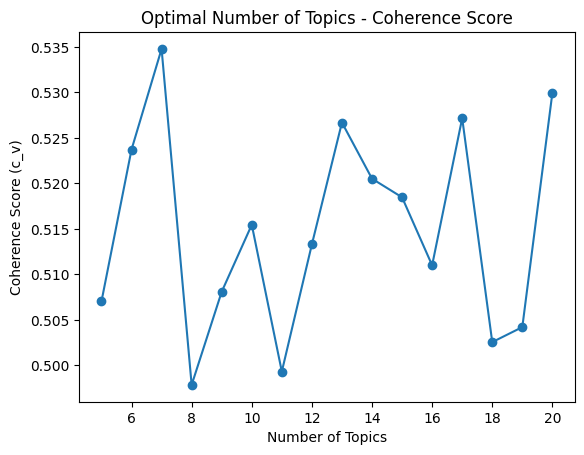

In [ ]:
import matplotlib.pyplot as plt

x = []
y = []
for num, score in coherence_values:
    x.append(num)
    y.append(score)

plt.plot(x, y, marker="o")
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score (c_v)")
plt.title("Optimal Number of Topics - Coherence Score")
plt.savefig("coherence_plot.png", bbox_inches="tight")
plt.show()

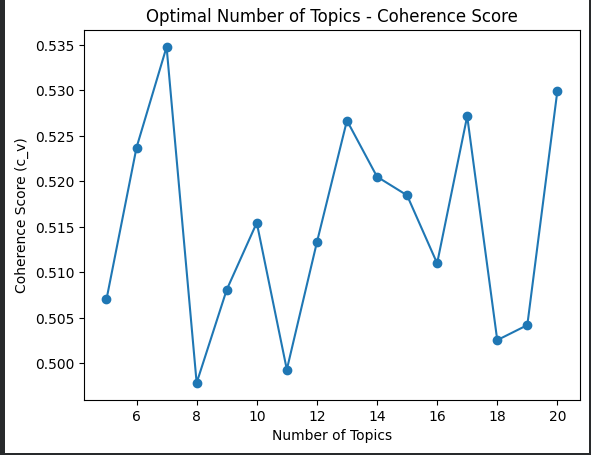

Determining best number of Topics from Plot

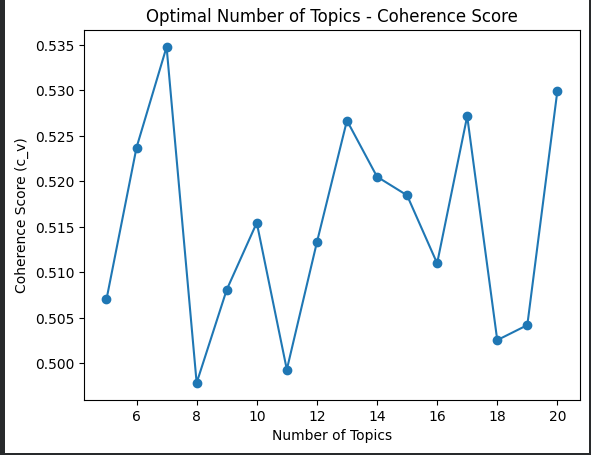

Best Number = 7 with 0.5348 as highest point.

Final LDA model

In [ ]:
best_num_topics = 7

from gensim.models import LdaMulticore

lda_model = LdaMulticore(
    corpus=corpus,
    id2word=dictionary,
    num_topics=best_num_topics,
    passes=20,
    iterations=100,
    chunksize=200,
    workers=3,
    random_state=100
)


pyLDAvis visualization

In [ ]:
!pip install pyLDAvis

import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

lda_vis = gensimvis.prepare(lda_model, corpus, dictionary)
pyLDAvis.save_html(lda_vis, "lda_vis.html")
pyLDAvis.display(lda_vis)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Top keywords per topic

In [ ]:
import pandas as pd

topics = lda_model.show_topics(num_topics=best_num_topics, num_words=20, formatted=False)

data = {"Topic": [], "Keywords": []}
for topic_num, topic_words in topics:
    keywords = []
    for word, prob in topic_words:
        keywords.append(word)
    data["Topic"].append(f"Topic {topic_num}")
    data["Keywords"].append(", ".join(keywords))

df_topic_keywords = pd.DataFrame(data)
df_topic_keywords.to_csv("topic_keywords.csv", index=False, encoding="utf-8-sig")
df_topic_keywords

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,Topic,Keywords
0,Topic 0,"app, use, great, good, easy, love, training, e..."
1,Topic 1,"time, gps, run, ride, speed, app, distance, mi..."
2,Topic 2,"ride, app, record, time, activity, rider, uplo..."
3,Topic 3,"segment, bike, other, rid, ride, add, like, ro..."
4,Topic 4,"app, great, track, keep, love, good, ride, cyc..."
5,Topic 5,"free, version, premium, app, pay, feature, use..."
6,Topic 6,"app, work, phone, update, use, fix, gps, andro..."


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Representative reviews per topic

In [ ]:
import pandas as pd

sample_reviews = {"Topic": [], "Probability": [], "RawReview": []}

for _, row in df.iterrows():
    original_review = row["content"]
    bow = lda_model.id2word.doc2bow(row["tokens"])
    topic_dist = lda_model.get_document_topics(bow)
    topic_dist = sorted(topic_dist, key=lambda x: x[1], reverse=True)
    topic_num, prob = topic_dist[0]
    sample_reviews["Topic"].append(topic_num)
    sample_reviews["Probability"].append(prob)
    sample_reviews["RawReview"].append(original_review)

df_samples = pd.DataFrame(sample_reviews)

top30_reviews_per_topic = (
    df_samples.sort_values(by="Probability", ascending=False)
              .groupby("Topic")
              .head(30)
              .sort_values(by="Topic")
              .reset_index(drop=True)
)

top30_reviews_per_topic.to_csv("top30_reviews_per_topic.csv", index=False, encoding="utf-8-sig")
top30_reviews_per_topic.head(20)

Die letzten 5000 Zeilen der Streamingausgabe wurden abgeschnitten.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime

,Topic,Probability,RawReview
0,0,0.933943,I really like the app. Offers a lot of informa...
1,0,0.933993,Best app going! Brilliant analysis of performa...
2,0,0.921942,Love this app. Its great for the serious cycli...
3,0,0.921879,"Great app, great features and I like that it w..."
4,0,0.921934,"Great mobile app, though the website has more ..."
5,0,0.928437,This app is fantastic for the newbie and the a...
6,0,0.928442,"Great app, will be good to launch more live co..."
7,0,0.921954,An amazing app I have used daily for more than...
8,0,0.921963,Easy to use. Good interface. It'd be even bett...
9,0,0.921935,Other fitness tracking apps have come and gone...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag